# 05 - End-to-end project: retention risk after onboarding

Business story:

> A SaaS company wants to know which customers are likely to churn after onboarding, and when the customer success team should intervene.

We will build this as a **landmark survival problem**.

- Landmark: day 30 after signup.
- Features: only behavior observed in the first 30 days.
- Event: churn after day 30.
- Censoring: customers still active when the study ends.

This design protects the model from future information. The pipeline is also deterministic end to end: there is no random number generator anywhere — every split below is a fixed calendar rule, so rerunning the notebook reproduces every number exactly.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.exceptions import ApproximationWarning, StatisticalWarning
from lifelines.statistics import proportional_hazard_test
from sklearn.preprocessing import StandardScaler

# Targeted filters only. A blanket warnings.filterwarnings("ignore") would also
# silence convergence and collinearity complaints — exactly the ones we want to hear.
warnings.filterwarnings("ignore", category=ApproximationWarning)
warnings.filterwarnings("ignore", category=StatisticalWarning)

raw = pd.read_csv(DATA_DIR / "subscription_retention_project.csv", parse_dates=["signup_date"])
raw.head()

,customer_id,signup_date,plan,acquisition_channel,region,company_size,annual_contract,first_30_logins,key_feature_events_30,support_tickets_30,payment_failures_30,onboarding_score_30,duration_days_since_signup,churn_observed,study_end_date
0,R00001,2024-09-08,Starter,Paid Search,North America,11-50,0,8,6,2,0,65.9,295,0,2025-06-30
1,R00002,2024-11-06,Starter,Paid Search,APAC,1-10,0,10,1,1,0,62.9,233,1,2025-06-30
2,R00003,2024-03-27,Starter,Paid Search,APAC,51-200,0,3,3,0,0,51.6,144,1,2025-06-30
3,R00004,2024-02-08,Growth,Partner,LATAM,1-10,0,8,4,0,0,58.0,508,0,2025-06-30
4,R00005,2024-12-01,Starter,Organic,North America,11-50,0,9,3,1,1,28.2,211,0,2025-06-30


## Step 1: define the modeling population

We only score customers who reached day 30 without observed churn. Customers who churned before day 30 are a different problem: early activation rescue, not post-onboarding retention.

Two details worth being precise about:

- **Eligibility is one condition, not two.** Reaching the landmark alive means `duration_days_since_signup > 30`, full stop. A tempting shortcut is to also admit any censored customer (`... | churn_observed == 0`) — coincidentally harmless on this data because the earliest censored duration is 182 days, but semantically wrong: it would let a customer censored at day 10 into the cohort with a negative post-landmark time, silently rescued by a `clip(1)`. The filter below needs no rescuing, and an `assert` replaces the clip so any future cohort bug fails loudly instead of quietly.
- **Boundary convention.** A churn at exactly day 30 belongs to the early-churn segment; the strict `>` keeps the landmark cohort clean. (This dataset has zero rows on that boundary.)

In [3]:
LANDMARK_DAY = 30

# Single eligibility condition: the customer was still around strictly after day 30.
landmark = raw[raw["duration_days_since_signup"] > LANDMARK_DAY].copy()
landmark["time_from_day30"] = landmark["duration_days_since_signup"] - LANDMARK_DAY

# Loud, not silent: a clip() here would paper over a broken cohort filter.
assert (landmark["time_from_day30"] > 0).all(), "landmark cohort contains non-positive event times"

print("raw customers:", len(raw))
print("eligible at day 30:", len(landmark))
print("excluded early churners:", len(raw) - len(landmark))
print("post-landmark churn rate:", round(landmark["churn_observed"].mean(), 3))

raw customers: 2600
eligible at day 30: 2464
excluded early churners: 136
post-landmark churn rate: 0.486


## Step 2: split like a future deployment

Random splits are sometimes fine for teaching, but production retention models usually face future customers. Here we train on earlier signups (before 2024-10-01) and test on later signups. This is harder and more honest.

Split discipline (field guide §4: split first, fit later, touch test once) applies to descriptive statistics too — even the baseline Kaplan-Meier below is fit on the **training cohort only**; the test cohort is described only at scoring time.

One printout below deserves a careful reading: the test event rate (≈0.39) sits well below train (≈0.52). That is **not** cohort drift. Test customers signed up later, so the 2025-06-30 study end gives them only 152–242 days of post-landmark follow-up (train: 243–516), and about 30% of them cannot be observed to the 180-day horizon at all. The gap is largely a follow-up artifact — which is exactly why every evaluation later in this notebook is censoring-aware.

In [4]:
cutoff = pd.Timestamp("2024-10-01")
train_raw = landmark[landmark["signup_date"] < cutoff].copy()
test_raw = landmark[landmark["signup_date"] >= cutoff].copy()

feature_cols = [
    "plan",
    "acquisition_channel",
    "region",
    "company_size",
    "annual_contract",
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
]
numeric_cols = [
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
]

def build_design(fit_df, score_df):
    """One-hot + standardize; every statistic is learned from fit_df only."""
    fit_X = pd.get_dummies(fit_df[feature_cols], drop_first=True)
    score_X = pd.get_dummies(score_df[feature_cols], drop_first=True)
    fit_X, score_X = fit_X.align(score_X, join="left", axis=1, fill_value=0)
    scaler = StandardScaler().fit(fit_X[numeric_cols])
    fit_X[numeric_cols] = scaler.transform(fit_X[numeric_cols])
    score_X[numeric_cols] = scaler.transform(score_X[numeric_cols])
    return fit_X, score_X

def attach_target(X, src):
    out = X.copy()
    out["time_from_day30"] = src["time_from_day30"].values
    out["churn_observed"] = src["churn_observed"].values
    return out

train_X, test_X = build_design(train_raw, test_raw)
train_model = attach_target(train_X, train_raw)
test_model = attach_target(test_X, test_raw)

print("train:", train_model.shape, "event rate:", round(train_model["churn_observed"].mean(), 3))
print("test:", test_model.shape, "event rate:", round(test_model["churn_observed"].mean(), 3))

# The event-rate gap is mostly administrative censoring, not drift: later signups
# simply have less runway before the study end.
study_end = pd.Timestamp(raw["study_end_date"].iloc[0])
follow_up_train = (study_end - train_raw["signup_date"]).dt.days - LANDMARK_DAY
follow_up_test = (study_end - test_raw["signup_date"]).dt.days - LANDMARK_DAY
print(f"post-landmark follow-up, train: {follow_up_train.min()}-{follow_up_train.max()} days")
print(f"post-landmark follow-up, test:  {follow_up_test.min()}-{follow_up_test.max()} days")
print("share of test customers unobservable to the 180-day horizon:",
      round((follow_up_test < 180).mean(), 3))

train: (1857, 19) event rate: 0.516
test: (607, 19) event rate: 0.392
post-landmark follow-up, train: 243-516 days
post-landmark follow-up, test:  152-242 days
share of test customers unobservable to the 180-day horizon: 0.297


### Baseline retention curve (train cohort only)

A single population-average Kaplan-Meier curve — fit on train, labeled as such — is the "no model" reference any risk tiering has to beat. All tabulated horizons are inside the observed train timeline.

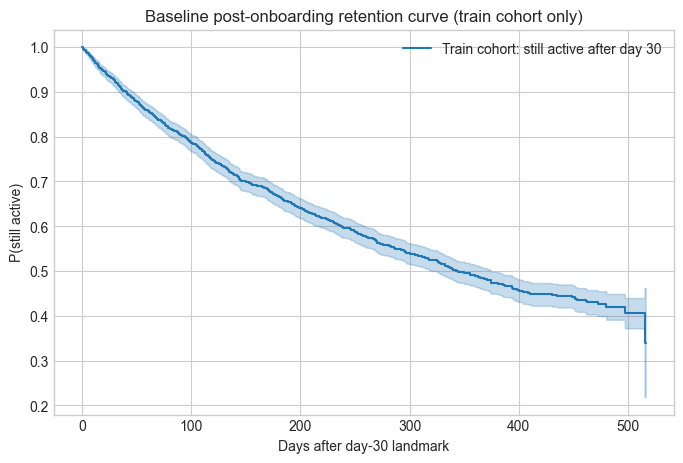

,days_after_day30,train_baseline_P_active
0,30,0.923
1,60,0.857
2,90,0.805
3,180,0.665
4,270,0.564


In [5]:
km = KaplanMeierFitter()
km.fit(
    train_model["time_from_day30"],
    train_model["churn_observed"],
    label="Train cohort: still active after day 30",
)

ax = km.plot_survival_function(figsize=(8, 5))
ax.set_title("Baseline post-onboarding retention curve (train cohort only)")
ax.set_xlabel("Days after day-30 landmark")
ax.set_ylabel("P(still active)")
plt.show()

pd.DataFrame({
    "days_after_day30": [30, 60, 90, 180, 270],
    "train_baseline_P_active": km.survival_function_at_times([30, 60, 90, 180, 270]).values.round(3),
})

## Step 3: select the model honestly, then interpret drivers

Two different jobs, two different fits (field guide §16: penalized Cox fits don't give valid p-values).

1. **Prediction fit.** The penalizer is a hyperparameter, so it is chosen by a validation protocol, never on test: split the train cohort temporally once more (train signups before 2024-08-01 fit the candidates, later train signups validate), pick the penalizer from {0, 0.01, 0.1} by validation concordance, refit on the full train cohort with the winner, then score the test cohort **exactly once**. This is the guide's split-first rule (§4) applied inside train: choose on validation, report once on test.
2. **Inference fit.** Ridge penalties bias coefficients and invalidate the naive standard errors, so p-values printed from a penalized fit are statistics theatre. For the quotable driver table we fit a separate **unpenalized** Cox on train. Events per variable are ample (959 events across 17 features ≈ 56 per variable), so the unpenalized fit is well-conditioned.

In [6]:
PENALIZER_GRID = [0.0, 0.01, 0.1]
inner_cutoff = pd.Timestamp("2024-08-01")

fit_raw = train_raw[train_raw["signup_date"] < inner_cutoff]
val_raw = train_raw[train_raw["signup_date"] >= inner_cutoff]
fit_X, val_X = build_design(fit_raw, val_raw)
fit_part = attach_target(fit_X, fit_raw)
val_part = attach_target(val_X, val_raw)
print(f"inner temporal split: fit={len(fit_part)} (signup < {inner_cutoff.date()}), validation={len(val_part)}")

val_scores = {}
for pen in PENALIZER_GRID:
    candidate = CoxPHFitter(penalizer=pen)
    candidate.fit(fit_part, duration_col="time_from_day30", event_col="churn_observed")
    val_scores[pen] = candidate.score(val_part, scoring_method="concordance_index")
    print(f"penalizer={pen:<4}  validation C-index={val_scores[pen]:.4f}")

best_penalizer = max(val_scores, key=val_scores.get)
print("selected penalizer:", best_penalizer)

# Refit on the FULL train cohort with the validated penalizer, then touch test exactly once.
cph = CoxPHFitter(penalizer=best_penalizer)
cph.fit(train_model, duration_col="time_from_day30", event_col="churn_observed")

print("Train concordance:", round(cph.concordance_index_, 3))
print("Future-cohort test concordance (scored once):",
      round(cph.score(test_model, scoring_method="concordance_index"), 3))

inner temporal split: fit=1421 (signup < 2024-08-01), validation=436
penalizer=0.0   validation C-index=0.7357
penalizer=0.01  validation C-index=0.7355


penalizer=0.1   validation C-index=0.7356


selected penalizer: 0.0
Train concordance: 0.732
Future-cohort test concordance (scored once): 0.72


### Driver table: the full picture, from the unpenalized fit

The table below is the **complete** hazard-ratio table — risk drivers at the top, protective drivers at the bottom. Truncating it would hide exactly the rows the retention story leans on (`annual_contract`, `onboarding_score_30`, `first_30_logins`).

Reading convention: the five numeric features are standardized, so their hazard ratios read **per +1 SD**; dummy features read against the dropped reference level of their category; `annual_contract` is a plain 0/1 contrast. Confidence intervals and p-values are valid here because the fit is unpenalized.

On this run the validation protocol selected penalizer 0.0, so the prediction fit and the inference fit happen to coincide numerically. The roles stay separate on principle: had validation preferred a ridge penalty, the penalized model would still do the scoring and this unpenalized fit would still do the talking.

In [7]:
inference_cph = CoxPHFitter()  # unpenalized: valid standard errors, CIs, and p-values
inference_cph.fit(train_model, duration_col="time_from_day30", event_col="churn_observed")

n_events = int(train_model["churn_observed"].sum())
n_features = train_X.shape[1]
print(f"events per variable: {n_events} events / {n_features} features = {n_events / n_features:.0f}")

hazard_table = (
    inference_cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
    .rename(columns={
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hr_ci_lower",
        "exp(coef) upper 95%": "hr_ci_upper",
    })
    .sort_values("hazard_ratio", ascending=False)
)
hazard_table.round(3)  # full table, no head(): protective drivers included

events per variable: 959 events / 17 features = 56


,hazard_ratio,hr_ci_lower,hr_ci_upper,p
covariate,,,,
plan_Starter,1.686,1.423,1.998,0.000
region_LATAM,1.256,0.980,1.610,0.072
acquisition_channel_Paid Search,1.231,1.056,1.435,0.008
support_tickets_30,1.214,1.124,1.311,0.000
region_Europe,1.165,0.946,1.434,0.151
payment_failures_30,1.164,1.097,1.235,0.000
company_size_11-50,1.136,0.980,1.316,0.090
company_size_51-200,1.129,0.936,1.362,0.205
region_North America,1.071,0.873,1.315,0.509


In [8]:
# Quotable hazard ratios come with an obligation: check proportional hazards on the
# same fit they were read from (guide §16, and notebook 04's diagnostic posture).
ph = proportional_hazard_test(inference_cph, train_model, time_transform="rank")
ph.summary.sort_values("p").round(4)

,test_statistic,p,-log2(p)
plan_Starter,5.1413,0.0234,5.4196
onboarding_score_30,2.8489,0.0914,3.4511
acquisition_channel_Paid Search,2.8176,0.0932,3.4230
plan_Scale,2.2180,0.1364,2.8740
acquisition_channel_Outbound,1.7687,0.1835,2.4458
company_size_11-50,1.0091,0.3151,1.6660
first_30_logins,0.8323,0.3616,1.4675
acquisition_channel_Partner,0.7886,0.3745,1.4168
key_feature_events_30,0.7839,0.3760,1.4113
annual_contract,0.7637,0.3822,1.3877


The screen flags one covariate: `plan_Starter` (p ≈ 0.02). Same posture as notebook 04 — a small p-value on this diagnostic means "look closer," not "refit everything." Concretely, read its hazard ratio of ≈1.69 as a **time-averaged effect** over the follow-up window: the Starter-plan hazard elevation drifts somewhat over time rather than holding perfectly constant, but the direction and rough magnitude of the average effect are what the retention team acts on. Every other covariate clears the screen (all p ≥ 0.09).

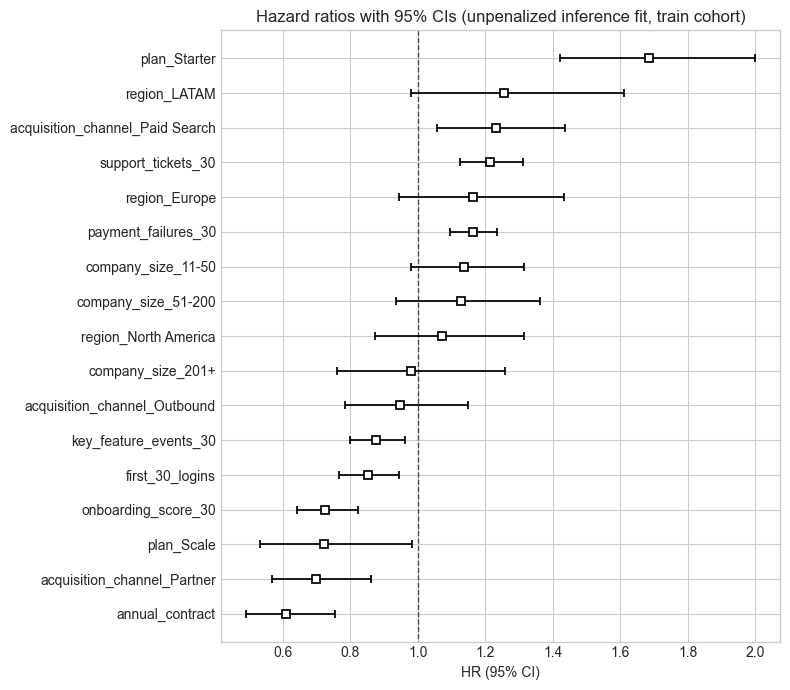

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
inference_cph.plot(hazard_ratios=True, ax=ax)
ax.set_title("Hazard ratios with 95% CIs (unpenalized inference fit, train cohort)")
plt.tight_layout()
plt.show()

## Step 4: produce a scorecard

A model becomes useful when it turns into an action table. We estimate survival forward from the day-30 landmark:

- `S_60d_after_day30`: probability the customer is still active 60 days after day 30, given active at day 30.
- `S_150d_after_day30`: same at 150 days — included because 150 is the longest horizon every test customer can actually be observed to (minimum test follow-up is 152 days), which makes it the honest evaluation horizon.
- `S_180d_after_day30`: the business's six-month planning horizon.
- `risk_tier`: an operational grouping whose cutoffs are **frozen on train** — the 70th and 90th percentiles of the training risk scores, applied as fixed thresholds to the test batch. Production cutoffs are frozen at training time; batch-relative percentiles would silently shift tier sizes with every scoring batch. The flip side: tier shares on a new batch will not be exactly 70/20/10 (here they land at 68/24/8), and that drift is information, not a bug.

Extrapolation check (guide §5): all three horizons sit comfortably inside the modelled range — the latest observed train event is 515 days after the landmark — so nothing below is extrapolated. If a requested horizon ever exceeded the train support, the rule is to cap Δ at the max modelled time and label the column accordingly.

In [10]:
HORIZONS = [60, 150, 180]
max_train_event_time = int(train_model.loc[train_model["churn_observed"] == 1, "time_from_day30"].max())
assert max(HORIZONS) <= max_train_event_time  # all horizons inside train support: no extrapolation
print("latest observed train event:", max_train_event_time, "days after the landmark")

surv = cph.predict_survival_function(test_X, times=HORIZONS).T
risk_score = cph.predict_partial_hazard(test_X).values.ravel()

# Freeze tier cutoffs on TRAIN: production thresholds are set once, at training time.
train_risk = cph.predict_partial_hazard(train_X).values.ravel()
tier_cutoffs = np.quantile(train_risk, [0.70, 0.90])
print("risk-score tier cutoffs (train 70th / 90th percentiles):", tier_cutoffs.round(3))

scorecard = test_raw[[
    "customer_id",
    "signup_date",
    "plan",
    "acquisition_channel",
    "region",
    "company_size",
    "annual_contract",
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
    "time_from_day30",
    "churn_observed",
]].copy()
scorecard["anchor"] = "day_30"  # every S column is conditional on being active at day 30
scorecard["risk_score"] = risk_score
scorecard["S_60d_after_day30"] = surv[60].values
scorecard["S_150d_after_day30"] = surv[150].values
scorecard["S_180d_after_day30"] = surv[180].values
scorecard["risk_tier"] = pd.cut(
    scorecard["risk_score"],
    bins=[-np.inf, tier_cutoffs[0], tier_cutoffs[1], np.inf],
    labels=["Monitor", "Customer success watchlist", "Immediate intervention"],
)

scorecard.sort_values("risk_score", ascending=False).head(10)

latest observed train event: 515 days after the landmark
risk-score tier cutoffs (train 70th / 90th percentiles): [1.747 3.354]


,customer_id,signup_date,plan,acquisition_channel,region,company_size,annual_contract,first_30_logins,key_feature_events_30,support_tickets_30,payment_failures_30,onboarding_score_30,time_from_day30,churn_observed,anchor,risk_score,S_60d_after_day30,S_150d_after_day30,S_180d_after_day30,risk_tier
2223,R02224,2024-11-01,Starter,Paid Search,North America,1-10,0,0,2,6,0,13.1,74,1,day_30,11.235625,0.300063,0.044803,0.026348,Immediate intervention
2451,R02452,2024-10-21,Starter,Organic,North America,1-10,0,5,1,3,1,8.3,32,1,day_30,8.003220,0.424242,0.109475,0.075005,Immediate intervention
103,R00104,2024-10-10,Starter,Organic,Europe,11-50,0,3,3,3,1,25.5,94,1,day_30,6.987240,0.473028,0.144967,0.104206,Immediate intervention
2220,R02221,2024-12-14,Starter,Paid Search,North America,11-50,0,2,1,2,0,13.1,80,1,day_30,6.448268,0.501147,0.168255,0.124065,Immediate intervention
2367,R02368,2024-11-19,Starter,Paid Search,North America,51-200,0,5,1,4,0,29.3,37,1,day_30,5.774809,0.538643,0.202678,0.154280,Immediate intervention
1988,R01989,2024-10-03,Starter,Paid Search,Europe,1-10,0,2,0,2,0,24.3,206,1,day_30,5.362829,0.562950,0.227123,0.176285,Immediate intervention
1980,R01981,2024-12-22,Starter,Paid Search,Europe,1-10,0,5,0,3,0,27.7,33,1,day_30,5.176414,0.574307,0.239132,0.187248,Immediate intervention
712,R00713,2024-10-19,Starter,Paid Search,Europe,1-10,0,4,0,2,0,21.3,7,1,day_30,5.168158,0.574815,0.239678,0.187749,Immediate intervention
786,R00787,2024-10-21,Starter,Partner,LATAM,11-50,0,2,1,3,0,12.4,222,0,day_30,5.122400,0.577640,0.242728,0.190550,Immediate intervention
136,R00137,2024-10-13,Starter,Paid Search,North America,11-50,0,1,0,2,0,32.3,19,1,day_30,5.072410,0.580742,0.246105,0.193658,Immediate intervention


### Tier table: censoring-aware evaluation

The naive `churn_ever_observed` column is kept for contrast, clearly labeled: it mixes unequal follow-up windows, and a censored customer counts as a non-churner no matter how short their window — so it is biased **downward** relative to true long-run churn and is not comparable to any fixed-horizon prediction.

The honest comparison is horizon-matched and censoring-aware: per tier, fit Kaplan-Meier on the test rows and read observed churn as 1 − KM(60) and 1 − KM(150), next to the model's average predicted churn 1 − S̄(60) and 1 − S̄(150). Both horizons lie within every test customer's observable window (minimum follow-up 152 days), so no tier's estimate rests on extrapolated tails. The concordance index reported in Step 3 is already censoring-aware and needs no such adjustment.

In [11]:
tier_rows = []
for tier, grp in scorecard.groupby("risk_tier", observed=True):
    km_tier = KaplanMeierFitter()
    km_tier.fit(grp["time_from_day30"], grp["churn_observed"])
    km_s60, km_s150 = km_tier.survival_function_at_times([60, 150]).values
    tier_rows.append({
        "risk_tier": tier,
        "customers": len(grp),
        "naive_churn_ever_observed": grp["churn_observed"].mean(),  # biased down: unequal follow-up
        "km_churn_by_60d": 1 - km_s60,
        "model_churn_by_60d": 1 - grp["S_60d_after_day30"].mean(),
        "km_churn_by_150d": 1 - km_s150,
        "model_churn_by_150d": 1 - grp["S_150d_after_day30"].mean(),
        "avg_first_30_logins": grp["first_30_logins"].mean(),
        "avg_onboarding_score": grp["onboarding_score_30"].mean(),
    })

pd.DataFrame(tier_rows).set_index("risk_tier").round(3)

,customers,naive_churn_ever_observed,km_churn_by_60d,model_churn_by_60d,km_churn_by_150d,model_churn_by_150d,avg_first_30_logins,avg_onboarding_score
risk_tier,,,,,,,,
Monitor,413,0.274,0.090,0.074,0.225,0.177,8.835,62.780
Customer success watchlist,146,0.596,0.281,0.227,0.534,0.482,5.260,41.455
Immediate intervention,48,0.792,0.500,0.380,0.750,0.700,3.708,29.879


In [12]:
out_path = OUTPUT_DIR / "retention_risk_scorecard.csv"
scorecard.to_csv(out_path, index=False)
print(f"Scorecard written to {out_path.relative_to(OUTPUT_DIR.parent.parent)}")
print("Provenance: backtest artifact — rows keep observed labels for evaluation; "
      "S columns are conditional on being active at day 30 (anchor='day_30'). "
      "Not a deployable scorecard as-is.")

Scorecard written to survival-analysis-intro/outputs/retention_risk_scorecard.csv
Provenance: backtest artifact — rows keep observed labels for evaluation; S columns are conditional on being active at day 30 (anchor='day_30'). Not a deployable scorecard as-is.


## Step 5: write the recommendation

A concise recommendation could be:

> Use the day-30 retention survival model for customers who complete onboarding without early churn. On a strictly later signup cohort it ranks churn risk well — test concordance 0.72, scored exactly once after validation-based penalizer selection — and the frozen-cutoff tiers separate cleanly: by 150 days after the landmark, censoring-aware observed churn is 75% in the Immediate-intervention tier, 53% on the watchlist, and 23% in Monitor, with the model's predicted churn tracking each tier. Prioritize the Immediate-intervention tier (48 accounts, 8% of this batch), especially accounts with low first-30-day usage, weak onboarding scores, payment failures, or unresolved support friction. The protective drivers are quotable with valid confidence intervals: annual contracts (HR 0.61), partner-sourced accounts (HR 0.70), and each additional standard deviation of onboarding score (HR 0.73) all materially reduce churn hazard.

What we would do before production:

- Confirm the event definition with finance and customer success.
- Backtest on multiple signup cohorts, not just one cutoff.
- Monitor calibration by risk tier, at horizons every scored customer can be observed to.
- Run an experiment to measure whether intervention changes retention.
- Refit on a schedule because onboarding behavior and customer mix drift — refreezing the tier cutoffs at each refit, never per batch.

Survival analysis is not just a model. It is a disciplined way to make time, uncertainty, and action fit together.